In [50]:
import numpy as np
import matplotlib.pyplot as plt

In [51]:
def convulation(x, h):
    N = len(x)
    M = len(h)
    y_len = N + M - 1
    y = np.zeros(y_len)


    for n in range(y_len):
        for k in range(M):
            if 0 <= n-k < N:
              y[n] += x[k] * h[n-k]
    return y


In [52]:
x1 = np.array([1, 2, 3, 4])
x2 = np.array([1, 1, 1, 1])

In [53]:
# y = np.convolve(x1, x2)
y = convulation(x1, x2)
len(y)

7

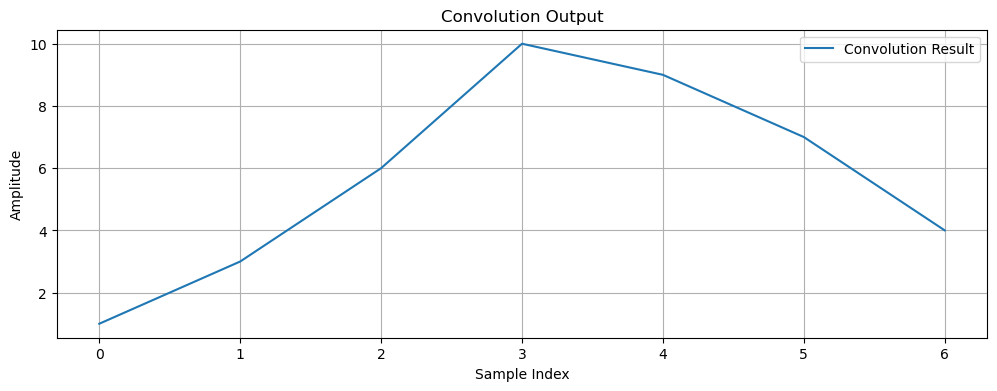

In [54]:
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(y)), y, label='Convolution Result')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Convolution Output')
plt.grid()
plt.legend()
plt.show()

In [55]:
def dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)
    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)
    return X

In [56]:
def idft(X):
    N = len(X)
    x = np.zeros(N, dtype=complex)
    for n in range(N):
        for k in range(N):
            x[n] += X[k] * np.exp(2j * np.pi * k * n / N)
    return x / N

In [57]:
x1 = np.concatenate((x1, np.zeros(len(y) - len(x1))))
x2 = np.concatenate((x2, np.zeros(len(y) - len(x2))))
X1 = dft(x1)
X2 = dft(x2)

In [58]:
Y = X1 * X2

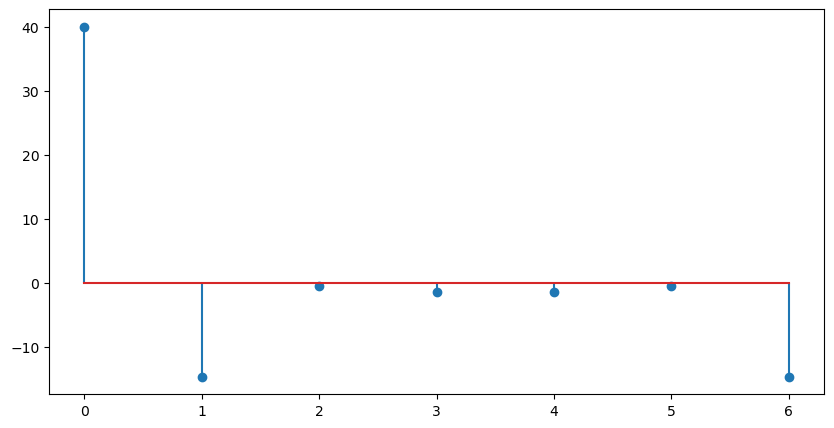

In [59]:
plt.figure(figsize=(10,5))
plt.stem(np.arange(len(Y)), Y)
plt.show()

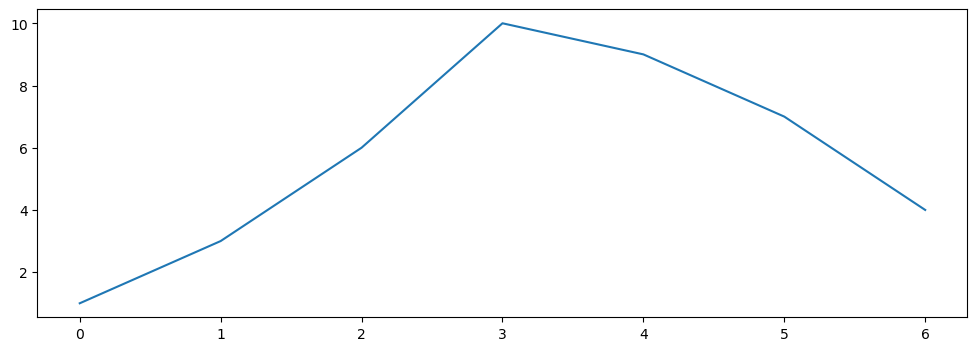

In [60]:
# yy = np.fft.ifft(Y)
yy = idft(Y)

plt.figure(figsize=(12,4))
plt.plot(np.arange(len(yy)), yy)
plt.show()

d:\Anaconda\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Anaconda\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


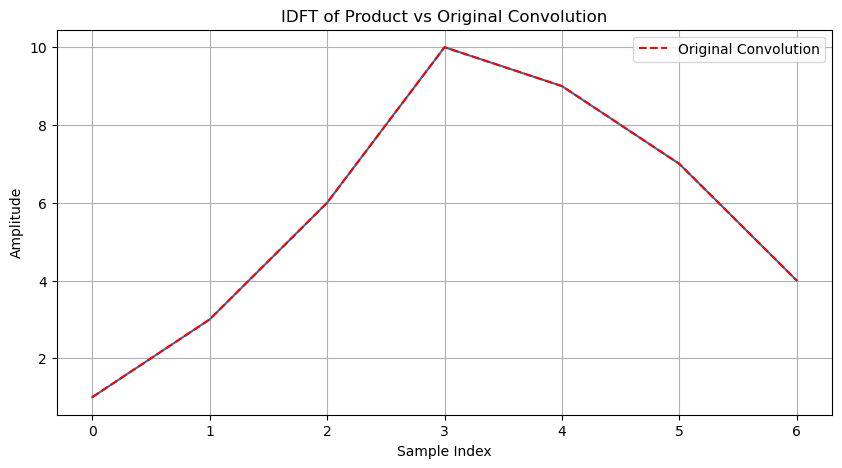

In [63]:
plt.figure(figsize=(10,5))
plt.plot(np.arange(len(yy)), yy)
plt.plot(np.arange(len(y)), y, 'r--', label='Original Convolution')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('IDFT of Product vs Original Convolution')
plt.grid()
plt.legend()
plt.show()
